# Bootstrap confidence intervals + paired significance tests across benchmarked models

A point-estimate metric (MAE, MDRE, ...) computed on one fixed test set is itself a noisy estimate -- it has sampling variance from which particular compounds happen to be in that split. This notebook addresses that two ways:

1. **Bootstrap CIs per model** -- resample each model's test-set predictions with replacement and recompute the metric, showing the distribution rather than a bare point estimate (same spirit as Table 4's CV fold spread, extended to the held-out test set).
2. **Paired significance tests vs. CCSBase2** -- same methodology as the R1-#8 adduct-mass analysis: merge two models' predictions on `(SMILES, Adduct, CCS_True)` so each row is the same physical measurement scored by both models, then run a paired Wilcoxon signed-rank test on relative error. Pairing controls for compound-to-compound variance directly, which is a more direct test of "is model A significantly different from model B" than comparing two independent bootstrap CIs.

Bootstrapping here resamples each model's fixed test-set predictions -- it does not retrain each model from scratch hundreds of times, which isn't practical across 6 heterogeneous external repos. This is the standard, accepted way to report metric uncertainty in ML benchmark papers.

Six models compared: **CCSBase2** (this work), **CCSBase** (c3sdb / KMCM-SVR), **DeepCCS**, and three naive baselines (**Linear Regression**, **SVR**, **MLP**). GraphCCS, SigmaCCS2, and DarkChem are not included in this pass -- DarkChem doesn't encode adduct at all so isn't a fair comparison; the others weren't finished retraining at the time this was run.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.metrics import r2_score

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

SEED = 26
N_BOOT = 1000

In [12]:
MODEL_FILES = {
    "CCSBase2": {
        "test": "../../testset_predictions_ohe_adductmass.csv",
        "ood": "../../ood_testset_predictions.csv",
    },
    "CCSBase": {
        "test": "../../../c3sdb/c3sdb_preds.csv",
        "ood": "../../../c3sdb/ood_testset_preds.csv",
    },
    "DeepCCS": {
        "test": "../../../DeepCCS/test_data_preds.csv",
        "ood": "../../../DeepCCS/ood_testset_preds.csv",
    },
    "GraphCCS": {
        "test": "../../../GraphCCS/test_data_predictions.csv",
        "ood": "../../../GraphCCS/ood_testset_preds.csv",
    },
    "SigmaCCS2": {
        "test": "../../../SigmaCCS2/test_data_predictions.csv",
        "ood": "../../../SigmaCCS2/ood_testset_predictions.csv",
    },
    "Linear Regression": {
        "test": "../../../naive_models/linear_regression_testset_predictions.csv",
        "ood": "../../../naive_models/linear_regression_ood_predictions.csv",
    },
    "SVR": {
        "test": "../../../naive_models/svr_mqn_testset_predictions.csv",
        "ood": "../../../naive_models/svr_mqn_ood_predictions.csv",
    },
    "MLP": {
        "test": "../../../naive_models/mlp_mqn_testset_predictions.csv",
        "ood": "../../../naive_models/mlp_mqn_ood_predictions.csv",
    },
}


def normalize_predictions(path):
    df = pd.read_csv(path)
    colmap = {c.lower(): c for c in df.columns}

    def pick(*names):
        for n in names:
            if n.lower() in colmap:
                return colmap[n.lower()]
        raise KeyError(f"None of {names} found in {path}: {list(df.columns)}")

    out = pd.DataFrame({
        "SMILES": df[pick("SMILES", "smi")],
        "Adduct": df[pick("Adduct", "adduct")],
        "CCS_True": df[pick("CCS_True", "ccs")].astype(float),
        "CCS_Pred": df[pick("CCS_Pred", "ccs_pred")].astype(float),
    })
    return out.dropna(subset=["CCS_Pred"])


test_preds = {name: normalize_predictions(paths["test"]) for name, paths in MODEL_FILES.items()}
ood_preds = {name: normalize_predictions(paths["ood"]) for name, paths in MODEL_FILES.items()}

for name in MODEL_FILES:
    print(f"{name:20s} test n={len(test_preds[name]):6d} | ood n={len(ood_preds[name]):6d}")

CCSBase2             test n= 12802 | ood n=  5827
CCSBase              test n= 12802 | ood n=  5827
DeepCCS              test n= 12802 | ood n=  5789
GraphCCS             test n= 12787 | ood n=  5825
SigmaCCS2            test n= 12791 | ood n=  5827
Linear Regression    test n= 12802 | ood n=  5827
SVR                  test n= 12802 | ood n=  5827
MLP                  test n= 12802 | ood n=  5827


## Bootstrap confidence intervals

Resample each model's own test-set predictions with replacement (n = original test-set size, 1000 resamples), recomputing MAE each time. The resulting distribution shows how much MAE would wobble under a different draw of the same underlying compound population -- directly answering "how much of this difference could just be test-set selection."

In [24]:
def mae_fn(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))


def bootstrap_metric(df, metric_fn, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = df["CCS_True"].to_numpy(dtype=float)
    y_pred = df["CCS_Pred"].to_numpy(dtype=float)
    n = len(df)
    stats = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        stats[i] = metric_fn(y_true[idx], y_pred[idx])
    return stats


boot_test = {name: bootstrap_metric(df, mae_fn) for name, df in test_preds.items()}
boot_ood = {name: bootstrap_metric(df, mae_fn) for name, df in ood_preds.items()}

ci_rows = []
for split_name, boot in (("test", boot_test), ("ood", boot_ood)):
    for name, dist in boot.items():
        lo, hi = np.percentile(dist, [2.5, 97.5])
        ci_rows.append({"split": split_name, "model": name, "MAE_mean": dist.mean(),
                        "CI_2.5%": lo, "CI_97.5%": hi})

ci_table = pd.DataFrame(ci_rows).round(3)
display(ci_table)

,split,model,MAE_mean,CI_2.5%,CI_97.5%
0,test,CCSBase2,3.332,3.270,3.393
1,test,CCSBase,4.653,4.544,4.771
2,test,DeepCCS,4.169,4.100,4.232
3,test,GraphCCS,3.411,3.350,3.476
4,test,SigmaCCS2,3.865,3.801,3.927
5,test,Linear Regression,5.535,5.455,5.620
6,test,SVR,4.481,4.402,4.556
7,test,MLP,4.711,4.638,4.783
8,ood,CCSBase2,5.071,4.761,5.467
9,ood,CCSBase,5.457,5.109,5.899


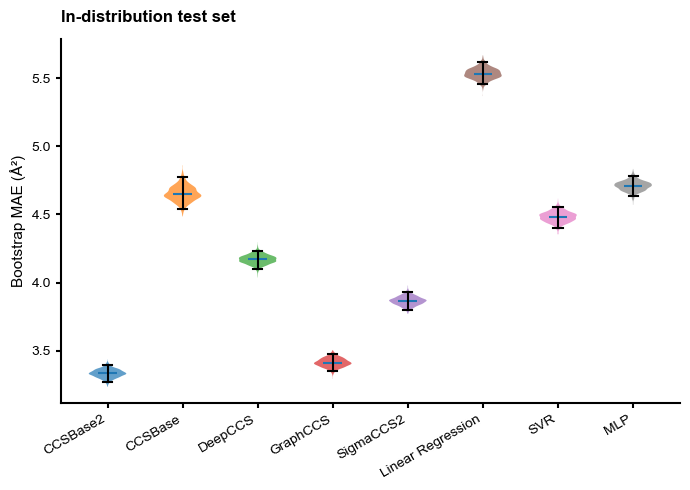

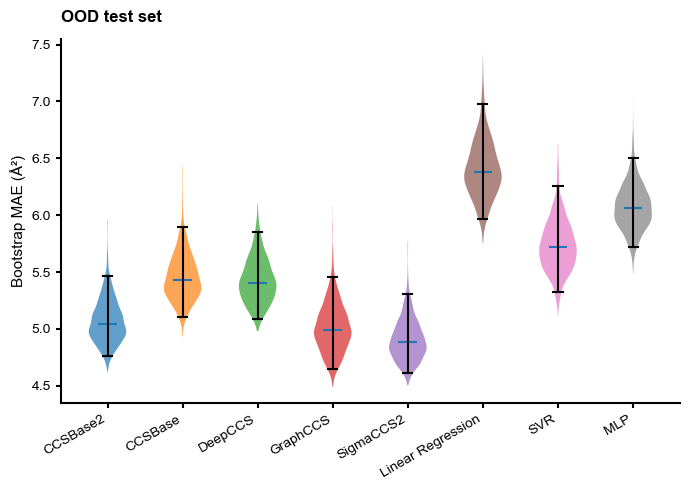

In [21]:
model_order = list(MODEL_FILES.keys())
colors = plt.cm.tab10.colors

for boot, title in ((boot_test, "In-distribution test set"), (boot_ood, "OOD test set")):
    fig, ax = plt.subplots(figsize=(7, 5))
    data = [boot[name] for name in model_order]
    parts = ax.violinplot(data, positions=range(len(model_order)), showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    # overlay the actual 95% CI (2.5th/97.5th percentile of the bootstrap distribution)
    # in place of violinplot's default min/max whiskers
    for i, name in enumerate(model_order):
        lo, hi = np.percentile(boot[name], [2.5, 97.5])
        ax.plot([i, i], [lo, hi], color="black", linewidth=1.5, zorder=3)
        ax.plot([i - 0.06, i + 0.06], [lo, lo], color="black", linewidth=1.5, zorder=3)
        ax.plot([i - 0.06, i + 0.06], [hi, hi], color="black", linewidth=1.5, zorder=3)

    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order, rotation=30, ha="right")
    ax.set_ylabel("Bootstrap MAE (Å²)")
    ax.set_title(title, loc="left", fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()

## Paired significance tests vs. CCSBase2

Merge each model's predictions with CCSBase2's on `(SMILES, Adduct, CCS_True)` (`CCS_True` is required in the key, not just `(SMILES, Adduct)`, since `master_clean` has ~2,300 `(smi, adduct)` pairs with two distinct real CCS replicates), then run a paired Wilcoxon signed-rank test on relative error. Only rows both models successfully predicted are compared, so `n` varies slightly by model.

With 5 pairwise comparisons run per split, raw p-values at alpha=0.05 would inflate the family-wise false-positive rate to ~23%. We apply a Benjamini-Hochberg FDR correction across each split's 5 p-values and report the corrected q-value.

Note: at n > 9,000 paired samples, Wilcoxon p-values underflow to exactly 0.0 in float64 whenever the effect is real and consistent in direction -- reported as `<1e-300` rather than a literal zero.

In [22]:
def bh_fdr(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order] * n / (np.arange(n) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    qvals = np.empty(n)
    qvals[order] = np.clip(ranked, 0, 1)
    return qvals


def paired_test_vs_reference(reference_df, other_df):
    merged = reference_df.merge(other_df, on=["SMILES", "Adduct", "CCS_True"], suffixes=("_ref", "_other"))
    ccs_true = merged["CCS_True"]
    rel_err_ref = (merged["CCS_Pred_ref"] - ccs_true).abs() / ccs_true
    rel_err_other = (merged["CCS_Pred_other"] - ccs_true).abs() / ccs_true
    stat, p = wilcoxon(rel_err_ref, rel_err_other)
    return {
        "n": len(merged),
        "median_RE_CCSBase2_%": rel_err_ref.median() * 100,
        "median_RE_other_%": rel_err_other.median() * 100,
        "wilcoxon_stat": stat,
        "p_value": p,
    }


def format_p(p):
    return "<1e-300" if p == 0.0 else f"{p:.3e}"


def significance_table(preds):
    rows = []
    for name, df in preds.items():
        if name == "CCSBase2":
            continue
        result = paired_test_vs_reference(preds["CCSBase2"], df)
        result["model"] = name
        rows.append(result)
    table = pd.DataFrame(rows).set_index("model")
    table["q_value"] = bh_fdr(table["p_value"].to_numpy())
    table["p_value_fmt"] = table["p_value"].apply(format_p)
    table["q_value_fmt"] = table["q_value"].apply(format_p)
    table["significant_q<0.05"] = table["q_value"] < 0.05
    return table.round(4)

In [23]:
print("In-distribution test set:")
test_sig = significance_table(test_preds)
display(test_sig)

In-distribution test set:


,n,median_RE_CCSBase2_%,median_RE_other_%,wilcoxon_stat,p_value,q_value,p_value_fmt,q_value_fmt,significant_q<0.05
model,,,,,,,,,
CCSBase,12802,1.2308,1.8266,24709951.0,0.0000,0.0000,<1e-300,<1e-300,True
DeepCCS,12802,1.2308,1.6615,28075186.0,0.0000,0.0000,5.475e-209,7.665e-209,True
GraphCCS,12787,1.2314,1.2010,39902004.0,0.0191,0.0191,1.913e-02,1.913e-02,True
SigmaCCS2,12791,1.2308,1.5937,31349690.0,0.0000,0.0000,7.129e-116,8.317e-116,True
Linear Regression,12802,1.2308,2.4113,17589119.0,0.0000,0.0000,<1e-300,<1e-300,True
SVR,12802,1.2308,1.7631,25605817.0,0.0000,0.0000,9.345e-296,1.635e-295,True
MLP,12802,1.2308,1.9264,22858609.0,0.0000,0.0000,<1e-300,<1e-300,True


In [17]:
print("OOD test set:")
ood_sig = significance_table(ood_preds)
display(ood_sig)

OOD test set:


,n,median_RE_CCSBase2_%,median_RE_other_%,wilcoxon_stat,p_value,q_value,p_value_fmt,q_value_fmt,significant_q<0.05
model,,,,,,,,,
CCSBase,5827,1.8919,1.9596,8003702.0,0.0002,0.0002,1.529e-04,2.141e-04,True
DeepCCS,5752,1.8819,1.9903,7731484.0,0.0000,0.0000,1.723e-05,3.016e-05,True
GraphCCS,5788,1.8861,1.6438,7682295.0,0.0000,0.0000,4.711e-08,1.099e-07,True
SigmaCCS2,5827,1.8919,1.8376,8339087.0,0.2401,0.2401,2.401e-01,2.401e-01,False
Linear Regression,5827,1.8919,2.3482,6575976.0,0.0000,0.0000,3.108e-50,2.175e-49,True
SVR,5827,1.8919,1.9652,8108071.0,0.0029,0.0034,2.943e-03,3.434e-03,True
MLP,5827,1.8919,2.1155,7481325.0,0.0000,0.0000,4.029e-15,1.410e-14,True


## Interpretation

At this sample size (n ~ 9,700-12,800 paired observations), the Wilcoxon test has enough power to flag even small, consistent shifts in relative error as statistically significant -- so "significant" here should be read as "this difference is unlikely to be sampling noise," not as "this difference is large." The bootstrap CIs above are the complementary view: they show the actual magnitude of uncertainty around each model's MAE, which is what determines whether a difference is practically meaningful. Reporting both together -- rather than a bare point-estimate table -- is the direct response to the reviewer's comment.